In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
data_path = "../data/rsem_counts_final/"

In [3]:
!ls $data_path

EcoKD1		     sample_controls.csv
HydraAHL	     sample_controls_without_temp_oxo.csv
HydraRecolonization  sample_descriptions.csv
HydraTemperature     sample_descriptions_without_temp_oxo.csv


In [5]:
samples = pd.read_csv(data_path + "sample_descriptions.csv")
samples.head()

,EXP,ID,sample,treatment,batch
0,HydraAHL,I27651-S1,3OC12_1,3OC12,1
1,HydraAHL,I27652-S1,3OC12_2,3OC12,1
2,HydraAHL,I27653-S1,3OC12_3,3OC12,1
3,HydraAHL,I27654-S1,3OC12_4,3OC12,1
4,HydraAHL,I27655-S1,3OC12_5,3OC12,1


In [10]:
eco_recol_samples = samples[samples["EXP"].isin(["EcoKD1","HydraRecolonization"])]
eco_recol_samples.head()

,EXP,ID,sample,treatment,batch
14,EcoKD1,I25727-L1,B8_1_TG12_1,Eco1KD_B8,e
15,EcoKD1,I25728-L1,B8_1_TG12_3,Eco1KD_B8,e
16,EcoKD1,I25729-L1,B8_1_Con12_1,control_B8,f
17,EcoKD1,I25730-L1,B8_1_Con12_3,control_B8,f
18,EcoKD1,I25731-L1,18166HP B8_1 TG 4,Eco1KD_B8,f


In [12]:
!ls $data_path"/EcoKD1"

I25727-L1.genes.results  I25734-L1.genes.results  I25741-L1.genes.results
I25728-L1.genes.results  I25735-L1.genes.results  I25742-L1.genes.results
I25729-L1.genes.results  I25736-L1.genes.results  I25743-L1.genes.results
I25730-L1.genes.results  I25737-L1.genes.results  I25744-L1.genes.results
I25731-L1.genes.results  I25738-L1.genes.results  I25745-L1.genes.results
I25732-L1.genes.results  I25739-L1.genes.results  I25746-L1.genes.results
I25733-L1.genes.results  I25740-L1.genes.results


In [83]:
tpm_df = pd.read_csv(data_path + "EcoKD1/I25727-L1.genes.results", sep="\t")
tpm_df = tpm_df[["gene_id","transcript_id(s)"]]
bad_files = ["I27673-S1","I27674-S1","I27675-S1","I27678-S1","I27681-S1","I27672-S1"]
for row in eco_recol_samples.iterrows():
    treatment = row[1].treatment
    file_id = row[1].ID
    if file_id in bad_files:
        print("[*] omitting file: {}".format(file_id))
    else:
        temp_df = pd.read_csv(data_path + row[1].EXP + "/" + file_id + ".genes.results", sep="\t")
        temp_df = temp_df[["gene_id","TPM"]]
        temp_df = temp_df.rename(columns={"TPM":treatment + "|" + file_id})
        tpm_df = tpm_df.merge(temp_df, on="gene_id")
        tpm_df = tpm_df.rename(columns = {treatment + "|" + file_id: treatment})

[*] omitting file: I27672-S1
[*] omitting file: I27673-S1
[*] omitting file: I27674-S1
[*] omitting file: I27675-S1
[*] omitting file: I27678-S1
[*] omitting file: I27681-S1


In [84]:
tpm_df = tpm_df.iloc[:, tpm_df.columns.argsort()]
tpm_df.head()

,Conventionalized,Conventionalized,Conventionalized,Cvbct,Cvbct,Cvbct,Eco1KD_B8,Eco1KD_B8,Eco1KD_B8,Eco1KD_B8,...,Wild,Wild,Wild,control_B8,control_B8,control_B8,control_B8,control_B8,gene_id,transcript_id(s)
0,0.00,0.00,0.00,0.00,0.00,0.20,0.0,0.00,0.0,0.00,...,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,HVAEP1.G000001,HVAEP1.T000001.1
1,4.85,3.85,4.28,2.99,3.28,3.24,2.2,1.89,1.4,1.42,...,4.26,4.50,4.07,0.0,0.01,0.02,0.01,0.03,HVAEP1.G000002,HVAEP1.T000002.1
2,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.00,...,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,HVAEP1.G000003,HVAEP1.T000003.1
3,0.10,0.10,0.06,0.00,0.00,0.11,0.0,0.06,0.0,0.07,...,0.00,0.04,0.00,0.0,0.00,0.02,0.00,0.15,HVAEP1.G000004,"HVAEP1.T000004.1,HVAEP1.T000004.2,HVAEP1.T0000..."
4,0.00,0.00,0.00,0.00,0.00,1.30,0.0,0.00,0.0,0.00,...,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,HVAEP1.G000005,HVAEP1.T000005.1


In [85]:
tpm_df["gene_id"] = tpm_df["gene_id"].apply(lambda x: x.split(".")[1])

In [86]:
frizzled_dict = {}
fz_df = tpm_df[tpm_df["gene_id"] == "G003966"]
for col in tpm_df.columns:
    if col != "gene_id" and col != "transcript_id(s)":
        frizzled_dict[col] = []
        for val in fz_df[col].values[0]:
            frizzled_dict[col].append(float(val))


In [87]:
frizzled_dict

{'Conventionalized': [14.31, 11.66, 14.12],
 'Cvbct': [16.39, 16.92, 12.9],
 'Eco1KD_B8': [10.04, 11.2, 11.3, 11.01],
 'GF': [24.15, 20.02, 20.14, 19.99],
 'Wild': [14.25, 15.37, 13.83],
 'control_B8': [13.49, 13.13, 13.64, 14.65, 13.0]}

In [89]:
df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in frizzled_dict.items()]))
print(df)

   Conventionalized  Cvbct  Eco1KD_B8     GF   Wild  control_B8
0             14.31  16.39      10.04  24.15  14.25       13.49
1             11.66  16.92      11.20  20.02  15.37       13.13
2             14.12  12.90      11.30  20.14  13.83       13.64
3               NaN    NaN      11.01  19.99    NaN       14.65
4               NaN    NaN        NaN    NaN    NaN       13.00


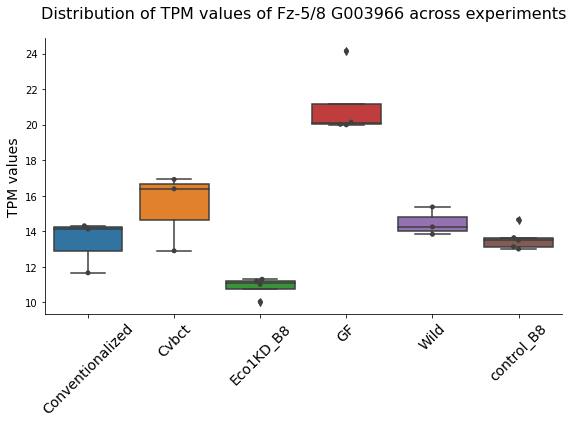

In [126]:
# melt dataframe into long format for seaborn
df_melted = df.melt(var_name="Sample", value_name="Value")

plt.figure(figsize=(8, 6))
sns.boxplot(x="Sample", y="Value", data=df_melted)
sns.swarmplot(x="Sample", y="Value", data=df_melted, color=".25")  # optional: overlay points

plt.title("Distribution of TPM values of Fz-5/8 G003966 across experiments",pad=20, fontsize=16)
plt.xlabel("")
plt.ylabel("TPM values", fontsize=14)
plt.xticks(rotation=45, ha='center', fontsize=14)
sns.despine(top=True, right=True)

plt.tight_layout()
#plt.show()
plt.savefig("../results/figures/frizzled_tpms.jpg",dpi=400)

In [106]:
# Drop NaNs for each group
clean_data = {k: pd.Series(v).dropna() for k, v in frizzled_dict.items()}

# Example: t-test
stat, p = stats.ttest_ind(clean_data["Eco1KD_B8"], clean_data["GF"])
print(f"T-test EcoKD1 vs GF: p={p:.4f}")

# Example: ANOVA
f_stat, p_val = stats.f_oneway(*clean_data.values())
print(f"ANOVA p={p_val:.4e}")

T-test EcoKD1 vs GF: p=0.0001
ANOVA p=5.6576e-07


In [123]:
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df_melted = df.melt(var_name="Sample", value_name="Value").dropna()

tukey = pairwise_tukeyhsd(df_melted['Value'], df_melted['Sample'], alpha=0.05)
print(tukey.summary())

        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
     group1        group2   meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------
Conventionalized      Cvbct     2.04 0.4874  -1.5925  5.6725  False
Conventionalized  Eco1KD_B8  -2.4758 0.2319  -5.8737  0.9221  False
Conventionalized         GF   7.7117  0.001   4.3138 11.1096   True
Conventionalized       Wild     1.12    0.9  -2.5125  4.7525  False
Conventionalized control_B8   0.2187    0.9  -3.0303  3.4677  False
           Cvbct  Eco1KD_B8  -4.5158 0.0063  -7.9137 -1.1179   True
           Cvbct         GF   5.6717  0.001   2.2738  9.0696   True
           Cvbct       Wild    -0.92    0.9  -4.5525  2.7125  False
           Cvbct control_B8  -1.8213 0.4891  -5.0703  1.4277  False
       Eco1KD_B8         GF  10.1875  0.001   7.0417 13.3333   True
       Eco1KD_B8       Wild   3.5958 0.0349   0.1979  6.9937   True
       Eco1KD_B8 control_B8   2.6945 0.0893  -0.